### Deep Learning

In [3]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [4]:
from google.colab import drive

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Sentiment140/cleaned_sentiment140.csv')

df.head()

Mounted at /content/drive


,Label,Serial,Date,Twitter_id,Clean_Text,Tokens
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,upset not update facebook texting ... might cr...,"['upset', 'not', 'update', 'facebook', 'textin..."
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,dived many times ball . managed save 50 % rest...,"['dived', 'many', 'times', 'ball', '.', 'manag..."
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,whole body feels itchy like fire,"['whole', 'body', 'feels', 'itchy', 'like', 'f..."
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,", not behaving . mad . not see .","[',', 'not', 'behaving', '.', 'mad', '.', 'not..."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,not whole crew,"['not', 'whole', 'crew']"


In [5]:
X = df["Clean_Text"].fillna("").astype(str)
y = df["Label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=11, shuffle=True,
                                                    stratify=y)

### Tokenizer

In [7]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=50000,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' ',
    char_level=False,
    oov_token="<OOV>",
    analyzer=None,
)

tokenizer.fit_on_texts(X_train)  # Vocabulary

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

### Tokenizer Analysis

In [8]:
Vocabulary_size = len(tokenizer.word_index)
print(f"Vocabulary Length: {Vocabulary_size}")

Vocabulary Length: 265097


In [9]:
print(list(tokenizer.word_index.items())[:20])

[('<OOV>', 1), ('not', 2), ('good', 3), ('going', 4), ('day', 5), ('get', 6), ('like', 7), ('go', 8), ('quot', 9), ('got', 10), ('today', 11), ('love', 12), ('work', 13), ('want', 14), ('lol', 15), ('time', 16), ('back', 17), ('know', 18), ('one', 19), ('really', 20)]


In [10]:
print(list(tokenizer.index_word.items())[:20])

[(1, '<OOV>'), (2, 'not'), (3, 'good'), (4, 'going'), (5, 'day'), (6, 'get'), (7, 'like'), (8, 'go'), (9, 'quot'), (10, 'got'), (11, 'today'), (12, 'love'), (13, 'work'), (14, 'want'), (15, 'lol'), (16, 'time'), (17, 'back'), (18, 'know'), (19, 'one'), (20, 'really')]


In [11]:
print(X_train.iloc[0])

twice today . good . thanks


In [12]:
print(X_train_sequences[0])

[1253, 11, 3, 27]


In [13]:
top20 = sorted(tokenizer.word_counts.items(),
               key = lambda x: x[1], reverse=True)[:20]

print(top20)

[('not', 281195), ('good', 72940), ('going', 71980), ('day', 69415), ('get', 65538), ('like', 62818), ('go', 59268), ('quot', 57680), ('got', 56420), ('today', 54574), ('love', 53630), ('work', 51961), ('want', 47324), ('lol', 47244), ('time', 46289), ('back', 45545), ('know', 45209), ('one', 43176), ('really', 40453), ('amp', 38995)]


### Padding

In [14]:
lengths = [len(seq) for seq in X_train_sequences]

pd.Series(lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

,0
count,1279999.0
mean,7.3
std,4.1
min,0.0
50%,7.0
75%,10.0
90%,13.0
95%,15.0
99%,18.0
max,58.0


In [15]:
X_train_padded = tf.keras.utils.pad_sequences(
    X_train_sequences,
    maxlen=18,
    dtype='int32',
    padding='post',
    truncating='post',
    value=0
)

X_test_padded = tf.keras.utils.pad_sequences(
    X_test_sequences,
    maxlen=18,
    dtype='int32',
    padding='post',
    truncating='post',
    value=0
)

In [16]:
print(X_train_sequences[0])

[1253, 11, 3, 27]


In [18]:
print(X_train_padded[:5])

[[ 1253    11     3    27     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]
 [  265  2982     2   267  1045     0     0     0     0     0     0     0
      0     0     0     0     0     0]
 [  222  2335 35014    72    43    30     1     0     0     0     0     0
      0     0     0     0     0     0]
 [ 2031    12     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]
 [    6  2008  1073    27   339  1584     0     0     0     0     0     0
      0     0     0     0     0     0]]


In [41]:
print(X_train_padded.shape)
print(X_test_padded.shape)

(1279999, 18)
(320000, 18)


### Simple RNN

In [42]:
input_dim = 50000
output_dim = 128
max_len = 25

In [43]:
model = tf.keras.Sequential()
model.add(keras.Input(shape=(max_len,)))
model.add(layers.Embedding(input_dim, output_dim, mask_zero=True))
model.add(layers.SimpleRNN(128, activation="tanh"))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

In [44]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

In [45]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/checkpoints/simple_rnn_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [46]:
history = model.fit(X_train_padded, y_train,
          epochs=5, batch_size=32,
          validation_split=0.2,
          callbacks=[early_stop])

Epoch 1/5
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 186s 6ms/step - accuracy: 0.7812 - auc: 0.8610 - loss: 0.4658 - val_accuracy: 0.7977 - val_auc: 0.8796 - val_loss: 0.4362
Epoch 2/5
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 177s 6ms/step - accuracy: 0.8046 - auc: 0.8854 - loss: 0.4270 - val_accuracy: 0.7975 - val_auc: 0.8822 - val_loss: 0.4361
Epoch 3/5
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 177s 6ms/step - accuracy: 0.8124 - auc: 0.8926 - loss: 0.4144 - val_accuracy: 0.8007 - val_auc: 0.8836 - val_loss: 0.4310
Epoch 4/5
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 177s 6ms/step - accuracy: 0.8170 - auc: 0.8969 - loss: 0.4066 - val_accuracy: 0.8002 - val_auc: 0.8825 - val_loss: 0.4335
Epoch 5/5
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 177s 6ms/step - accuracy: 0.8200 - auc: 0.8995 - loss: 0.4017 - val_accuracy: 0.7991 - val_auc: 0.8822 - val_loss: 0.4322


In [47]:
model.evaluate(X_test_padded, y_test, batch_size=32, verbose=2)

10000/10000 - 28s - 3ms/step - accuracy: 0.7966 - auc: 0.8792 - loss: 0.4369


[0.436870276927948, 0.7966499924659729, 0.8791806697845459]

In [48]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

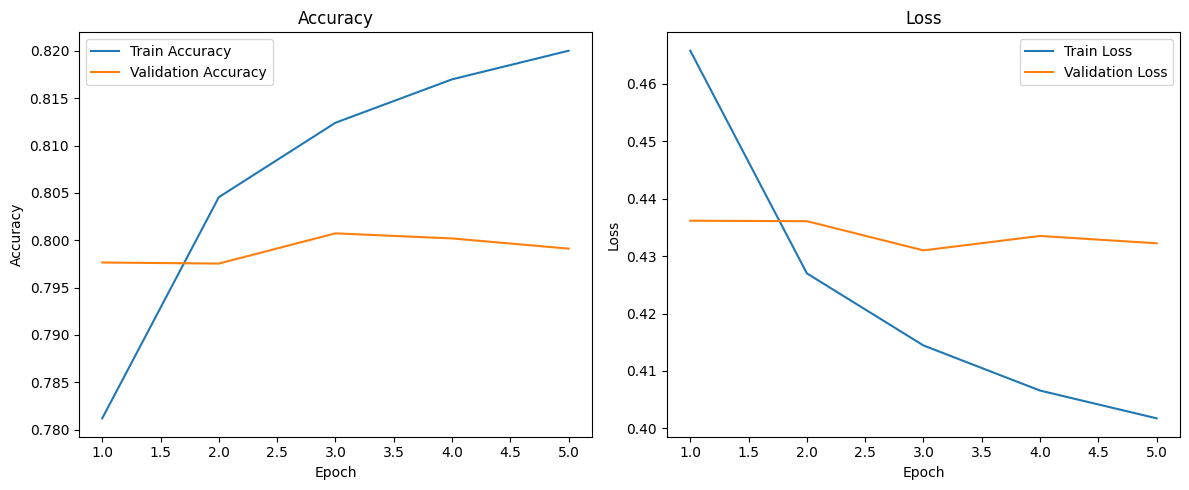

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### LSTM

In [58]:
model = tf.keras.Sequential()
model.add(keras.Input(shape=(max_len,)))
model.add(layers.Embedding(input_dim, output_dim, mask_zero=True))
model.add(layers.LSTM(128, activation="tanh", use_cudnn=Fasle))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

In [59]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

In [60]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/checkpoints/LSTM_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [61]:
history = model.fit(X_train_padded, y_train,
          epochs=5, batch_size=32,
          validation_split=0.2,
          callbacks=[early_stop])

Epoch 1/5
    1/32000 ━━━━━━━━━━━━━━━━━━━━ 21:28:48 2s/step - accuracy: 0.6875 - auc: 0.4708 - loss: 0.6915

InvalidArgumentError: Graph execution error:

Detected at node sequential_4_1/lstm_2_1/Assert/Assert defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3

In [ ]:
model.evaluate(X_test_padded, y_test, batch_size=32, verbose=2)

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### BiLSTM

In [ ]:
model = tf.keras.Sequential()
model.add(keras.Input(shape=(max_len,)))
model.add(layers.Embedding(input_dim, output_dim, mask_zero=True))
model.add(layers.Bidirectional(layers.LSTM(128, activation="tanh")))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

In [ ]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/checkpoints/BiLSTM_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(X_train_padded, y_train,
          epochs=5, batch_size=32,
          validation_split=0.2,
          callbacks=[early_stop])

In [ ]:
model.evaluate(X_test_padded, y_test, batch_size=32, verbose=2)

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### GRU

In [ ]:
model = keras.Sequential()
model.add(keras.Input(shape=(max_len,)))
model.add(layers.GRU(128, activation='tanh'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

In [ ]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/checkpoints/GRU_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(X_train_padded, y_train,
          epochs=5, batch_size=32,
          validation_split=0.2,
          callbacks=[early_stop])

In [ ]:
model.evaluate(X_test_padded, y_test, batch_size=32, verbose=2)

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()